In [3]:
!pip3 install lightgbm
!pip3 install matplotlib
!pip3 install pandas
!pip3 install sklearn
!pip3 install statistics
!pip3 install xgboost

from statistics import LinearRegression
import pandas as pd
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.calibration import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used b

In [4]:
# [x] merchant account age = now - merchants.created_at
# [x] merchant balance = merchant_balances.balance
# [x] period since last transaction = now - merchant_balances.updated_at
# [ ] platform total profit from a merchant
# [ ] platform last month profit from a merchant

# is_dropped_out = merchant.status != 'active'

In [5]:
df_merchants = pd.read_csv ('merchants.csv')
df_merchants

,id,created_at,status,market,vat_percentage
0,abc0001025,2020-01-21 07:23:19.224+00,suspend,NaN,0.0
1,abc0001026,2020-02-06 07:57:42.329+00,active,NaN,0.0
2,abc0001027,2020-02-08 06:40:58.3+00,active,CA,0.0
3,abc0001028,2020-02-12 01:09:57.698+00,active,HK,0.0
4,abc0001029,2020-02-12 01:12:06.553+00,suspend,NaN,0.0
...,...,...,...,...,...
24790,abc0028836,2024-03-21 06:56:43.223+00,active,IN,0.0
24791,abc0028837,2024-03-21 07:54:19.51+00,active,PE,0.0
24792,abc0028838,2024-03-21 11:43:55.169+00,active,SG,0.0
24793,abc0028839,2024-03-21 12:50:44.921+00,active,NaN,0.0


In [6]:
df_merchants['created_at'].value_counts()

2020-01-21 07:23:19.224+00    1
2022-11-02 12:59:17.449+00    1
2022-11-01 15:28:24.392+00    1
2022-11-01 15:27:15.966+00    1
2022-11-01 14:40:36.404+00    1
                             ..
2022-01-08 04:34:06.472+00    1
2022-01-08 02:38:53.555+00    1
2022-01-08 00:31:38.61+00     1
2022-01-08 00:13:53.658+00    1
2024-03-21 13:00:22.698+00    1
Name: created_at, Length: 24795, dtype: int64

In [7]:
now = pd.to_datetime("today").tz_localize('Singapore')

In [8]:
df_merchant_created = pd.DataFrame()

df_merchant_created['merchant_id'] = df_merchants['id']
df_merchant_created['created_at'] = df_merchants['created_at']

# days since created
df_merchant_created['account_age_days'] = (now - pd.to_datetime(df_merchants['created_at'], format = '%Y-%m-%d %H:%M:%S.%f')).dt.days
df_merchant_created['is_dropped_out'] = df_merchants['status'] != 'active'
df_merchant_created['dropped_out'] = df_merchant_created['is_dropped_out'].astype(int)

df_merchant_created

,merchant_id,created_at,account_age_days,is_dropped_out,dropped_out
0,abc0001025,2020-01-21 07:23:19.224+00,1879,True,1
1,abc0001026,2020-02-06 07:57:42.329+00,1863,False,0
2,abc0001027,2020-02-08 06:40:58.3+00,1861,False,0
3,abc0001028,2020-02-12 01:09:57.698+00,1858,False,0
4,abc0001029,2020-02-12 01:12:06.553+00,1858,True,1
...,...,...,...,...,...
24790,abc0028836,2024-03-21 06:56:43.223+00,358,False,0
24791,abc0028837,2024-03-21 07:54:19.51+00,358,False,0
24792,abc0028838,2024-03-21 11:43:55.169+00,358,False,0
24793,abc0028839,2024-03-21 12:50:44.921+00,358,False,0


In [9]:
df_merchant_balances = pd.read_csv ('merchant_balances.csv')
df_merchant_balances


,merchant_id,updated_at,currency,balance,balance_type
0,abc0001025,2020-01-23 06:14:50.16+00,SGD,0.0000,test
1,abc0001025,2020-11-30 04:40:41.307+00,NaN,-5.4100,test
2,abc0001026,2023-03-30 02:07:06.986+00,NaN,894.3800,test
3,abc0001028,2023-07-18 01:51:29.279+00,NaN,-299447.5256,real
4,abc0001031,2023-03-30 02:07:07.321+00,NaN,613.9500,test
...,...,...,...,...,...
9322,abc0028817,2024-03-22 05:33:25.283+00,NaN,11.7805,test
9323,abc0028829,2024-03-22 00:22:13.085+00,NaN,0.0000,test
9324,abc0021501,2024-03-23 00:17:24.744+00,NaN,0.0000,real
9325,abc0028850,2024-03-23 00:23:09.548+00,NaN,0.0000,test


In [10]:
df_merchant_balances = df_merchant_balances[(df_merchant_balances['balance_type'] == 'real') & (df_merchant_balances['currency'].isna())]
df_merchant_balances

,merchant_id,updated_at,currency,balance,balance_type
3,abc0001028,2023-07-18 01:51:29.279+00,NaN,-2.994475e+05,real
7,abc0001029,2021-10-25 02:32:54.922+00,NaN,-1.304446e+06,real
8,abc0001038,2021-10-02 00:01:16.592+00,NaN,-3.658745e+05,real
10,abc0001037,2021-10-02 00:01:16.551+00,NaN,3.000000e+00,real
13,abc0001047,2021-10-02 00:01:16.749+00,NaN,9.680000e+00,real
...,...,...,...,...,...
9316,abc0027514,2024-03-22 00:21:07.663+00,NaN,0.000000e+00,real
9317,abc0027747,2024-03-22 00:21:19.587+00,NaN,0.000000e+00,real
9321,abc0028721,2024-03-22 00:22:07.654+00,NaN,0.000000e+00,real
9324,abc0021501,2024-03-23 00:17:24.744+00,NaN,0.000000e+00,real


In [11]:
# days since created
df_merchant_balances['days_since_last_tx'] = (now - pd.to_datetime(df_merchant_balances['updated_at'], format = '%Y-%m-%d %H:%M:%S.%f')).dt.days

df_merchant_balances

/var/folders/pr/41mxfp_n4ybcjhbgqc5glymc0000gn/T/ipykernel_42058/1960503968.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merchant_balances['days_since_last_tx'] = (now - pd.to_datetime(df_merchant_balances['updated_at'], format = '%Y-%m-%d %H:%M:%S.%f')).dt.days


,merchant_id,updated_at,currency,balance,balance_type,days_since_last_tx
3,abc0001028,2023-07-18 01:51:29.279+00,NaN,-2.994475e+05,real,606
7,abc0001029,2021-10-25 02:32:54.922+00,NaN,-1.304446e+06,real,1236
8,abc0001038,2021-10-02 00:01:16.592+00,NaN,-3.658745e+05,real,1260
10,abc0001037,2021-10-02 00:01:16.551+00,NaN,3.000000e+00,real,1260
13,abc0001047,2021-10-02 00:01:16.749+00,NaN,9.680000e+00,real,1260
...,...,...,...,...,...,...
9316,abc0027514,2024-03-22 00:21:07.663+00,NaN,0.000000e+00,real,358
9317,abc0027747,2024-03-22 00:21:19.587+00,NaN,0.000000e+00,real,358
9321,abc0028721,2024-03-22 00:22:07.654+00,NaN,0.000000e+00,real,358
9324,abc0021501,2024-03-23 00:17:24.744+00,NaN,0.000000e+00,real,357


In [12]:
df_merchant_created_balance = pd.merge(df_merchant_created, df_merchant_balances, left_on='merchant_id', right_on='merchant_id')
df_merchant_created_balance

,merchant_id,created_at,account_age_days,is_dropped_out,dropped_out,updated_at,currency,balance,balance_type,days_since_last_tx
0,abc0001025,2020-01-21 07:23:19.224+00,1879,True,1,2021-10-01 04:37:09.869+00,NaN,0.000000e+00,real,1260
1,abc0001026,2020-02-06 07:57:42.329+00,1863,False,0,2024-01-29 13:26:41.176+00,NaN,-1.603000e+01,real,410
2,abc0001027,2020-02-08 06:40:58.3+00,1861,False,0,2024-02-11 00:00:25.611+00,NaN,-2.746232e+05,real,398
3,abc0001028,2020-02-12 01:09:57.698+00,1858,False,0,2023-07-18 01:51:29.279+00,NaN,-2.994475e+05,real,606
4,abc0001029,2020-02-12 01:12:06.553+00,1858,True,1,2021-10-25 02:32:54.922+00,NaN,-1.304446e+06,real,1236
...,...,...,...,...,...,...,...,...,...,...
6414,abc0028721,2024-03-11 19:43:33.564+00,368,False,0,2024-03-22 00:22:07.654+00,NaN,0.000000e+00,real,358
6415,abc0028744,2024-03-13 07:48:09.199+00,366,False,0,2024-03-20 00:22:06.989+00,NaN,-3.941009e+03,real,360
6416,abc0028750,2024-03-13 12:58:06.445+00,366,False,0,2024-03-23 07:24:12.367+00,NaN,1.074516e+03,real,356
6417,abc0028781,2024-03-15 12:47:43.574+00,364,False,0,2024-03-22 13:49:28.553+00,NaN,7.550260e+03,real,357


In [13]:
df_merchant_created_balance[df_merchant_created_balance['merchant_id'] == 'abc0028490']

,merchant_id,created_at,account_age_days,is_dropped_out,dropped_out,updated_at,currency,balance,balance_type,days_since_last_tx
6398,abc0028490,2024-02-16 07:49:07.225+00,392,False,0,2024-03-23 07:59:21.722+00,NaN,-21769.183,real,356


In [14]:
df_features = df_merchant_created_balance[['merchant_id', 'account_age_days', 'balance', 'days_since_last_tx', 'dropped_out']]
df_features

,merchant_id,account_age_days,balance,days_since_last_tx,dropped_out
0,abc0001025,1879,0.000000e+00,1260,1
1,abc0001026,1863,-1.603000e+01,410,0
2,abc0001027,1861,-2.746232e+05,398,0
3,abc0001028,1858,-2.994475e+05,606,0
4,abc0001029,1858,-1.304446e+06,1236,1
...,...,...,...,...,...
6414,abc0028721,368,0.000000e+00,358,0
6415,abc0028744,366,-3.941009e+03,360,0
6416,abc0028750,366,1.074516e+03,356,0
6417,abc0028781,364,7.550260e+03,357,0


In [15]:
df_features.to_csv ("merchant_dropout_preprocessed.csv", index=False)

In [16]:
X = df_features[['account_age_days', 'balance', 'days_since_last_tx']]
y = df_features['dropped_out']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)
X_train

,account_age_days,balance,days_since_last_tx
137,1707,0.00,1260
2480,1427,0.00,1346
3551,1252,0.00,1252
2212,1450,0.00,1346
6238,574,4.95,571
...,...,...,...
6202,637,0.00,603
2325,1439,0.00,1346
2303,1442,0.00,1346
3392,1286,0.00,1286


In [17]:
# classification = RandomForestClassifier()
classification = XGBClassifier()

pipeline = Pipeline(steps = [('classification', classification)])

pipeline.fit(X_train, y_train)

pipeline.named_steps['classification']

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [18]:
y_pred = pipeline.predict(X_test)
y_pred

data = {'Actual': y_test, 'Predicted': y_pred}

df_result = pd.DataFrame(data)
df_result

,Actual,Predicted
4834,1,1
2902,1,1
1323,1,1
3953,1,1
3374,1,1
...,...,...
328,1,1
5881,1,1
3498,1,1
4610,1,1


In [19]:
pipeline.named_steps['classification'].score(X_test, y_test)

0.9392523364485982

In [20]:
from sklearn.metrics import confusion_matrix

mt = confusion_matrix(y_test, y_pred)
mt

array([[ 135,   59],
       [  19, 1071]])

In [21]:
df_mt = pd.DataFrame(mt, index = ['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'Predicted 1'])
df_mt

,Predicted 0,Predicted 1
Actual 0,135,59
Actual 1,19,1071


<Axes: >

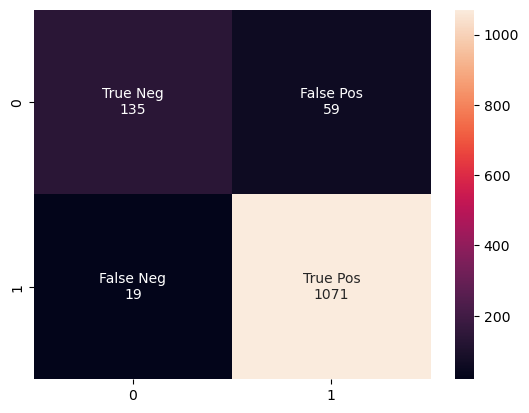

In [22]:
import numpy as np
import seaborn as sns

conf_mat=confusion_matrix(y_test, y_pred) 
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(conf_mat, annot=labels, fmt="")

In [23]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.70      0.78       194
           1       0.95      0.98      0.96      1090

    accuracy                           0.94      1284
   macro avg       0.91      0.84      0.87      1284
weighted avg       0.94      0.94      0.94      1284



In [24]:
y_pred_proba = pipeline.predict_proba(X_test)
y_pred_proba

array([[7.1187198e-02, 9.2881280e-01],
       [6.6971779e-04, 9.9933028e-01],
       [1.6248226e-04, 9.9983752e-01],
       ...,
       [4.1121000e-01, 5.8879000e-01],
       [1.2552541e-01, 8.7447459e-01],
       [9.2514157e-03, 9.9074858e-01]], dtype=float32)

In [25]:
from sklearn.metrics import roc_curve
fpr, tpr, thres = roc_curve(y_test, y_pred_proba[:,1])
fpr, tpr

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.01030928, 0.01030928, 0.01030928,
        0.01030928, 0.01030928, 0.01030928, 0.01030928, 0.01030928,
        0.01030928, 0.01030928, 0.01030928, 0.01030928, 0.01030928,
        0.01030928, 0.01030928, 0.01030928, 0.01030928, 0.01030928,
        0.01030928, 0.01030928, 0.01030928, 0.01030928, 0.01030928,
        0.01030928, 0.01030928, 0.01030928, 0.01030928, 0.01030928,
        0.01030928, 0.01030928, 0.01546392, 0.01546392, 0.01546392,
        0.01546392, 0.01546392, 0.01546392, 0.01546392, 0.01546392,
        0.01546392, 0.01546392, 0.01546392, 0.01546392, 0.01546392,
        0.01546392, 0.01546392, 0.01546392, 0.01546392, 0.01546392,
        0.01546392, 0.01546392, 0.01546392, 0.02061856, 0.02061856,
        0.02061856, 0.0257732 , 0.0257732 , 0.0257732 , 0.0257732 ,
        0.03092784, 0.03092784, 0.03092784, 0.03

In [26]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba[:,1])
# good if auc is close to 1
auc

0.9375626596046533

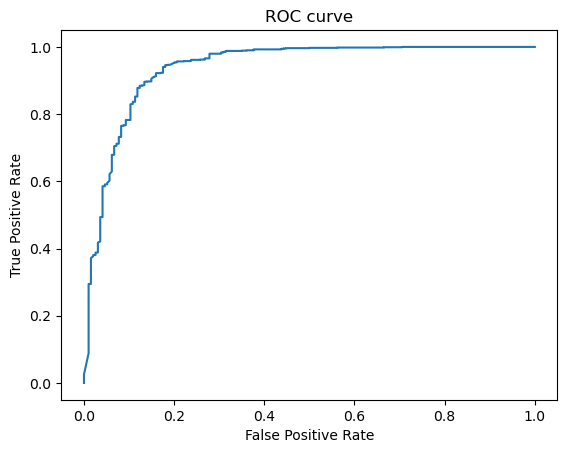

In [27]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()